In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def  femcode2(p,f):
##    Soluci\'on de la ecuaci\'on de Laplace 
##    -div(grad u(x))=f(x)
##     u(x,y)|(boundary Omega)=0
##    Empleando funciones trial-test lineales phi
##    sobre mallas estructuradas con celdas divididas en 2 tri\'ngulos
##    siguiendo la diagonal "principal"
##    (muy est?ndar)
    n=len(p) #Tama\~no de la malla
    t=np.block([np.arange(0,n-1).reshape(n-1,1),np.arange(1,n).reshape(n-1,1)])
    # t tiene la lista de los 2 nodos de cada elementos en una matriz de T
    # por 3
    b=np.array([0,n-1]) # left, right
    # b = n\'umeros de los nodos de la frontera
    T=n-1 #n\'umero de elementos
    # p lista las coordenadas x,y de los N nodos
    # t lista los 3 n\'umeros de nodo de los elementos
    K=np.zeros((n,n)) # Matriz cero
    F=np.zeros(n) # vector de cargas F para almacenar las integrales  phi \times f(x,y)
    
    for e in range(T):  # Integraci\'on sobre los elementos triangulares
      nodes=t[e,:] # nodos del tri\'angulo e
      Pe=np.block([np.ones((2,1)),p[nodes.astype(int).reshape(2,1)]]) # Matriz 2 por 2 matrix con filas=[1 xcorner ycorner] 
      Area=np.abs(np.diff(p[nodes.astype(int)])) # \'area del tri\'angulo e
      C=np.linalg.inv(Pe) # columnas de C son los coeffs en a+bx+cy para dar phi=1,0,0 en los nodos
      # ahora se calculan Ke de 2 por 2 Ke y  Fe de 3 por 1 para el elemento e
      grad=C[1:2,:]
      pm=np.mean(p[nodes.astype(int)],0)
      Ke=Area*np.dot(grad.T,grad)  
      Fe=Area/2*f(pm)  # integral de phi*f sobre el tri\'angulo 
      ## es el volumen de la pir\'amide por f evaluada en el centroide
      # El centroide es  mean(p(nodes,:)) = promedio de las coordenadas 2 de
      # los 2 nodos
      #
      # Se suma Ke a las 9 entradas de la matriz global K
      K[nodes.astype(int).reshape(2,1),nodes.astype(int)]+=Ke
      F[nodes.astype(int)]+=Fe # Se suma Fe a las 2 componentes del vector de carga F
    
    # Ahora de a\~naden las condiciones de Dirichlet homogéneas en K and F 
    for i in range(len(b)):
        K[b[i],:]=np.zeros(K.shape[0])  #Ponemos ceros para no modificar los valores en la frontera
        K[:,b[i]]=np.zeros(K.shape[0])  
    for i in range(len(b)):
        K[b[i],b[i]]=1 # se pone I  en la submatriz "frontera" de K
        F[b[i]]=0
    # Ahora resolvemos
    U=np.linalg.solve(K,F)
    # La aproximaci\'on es U_1 phi_1 + ... + U_N phi_N
    # Se grafica la aproximaci\'?n U(x,y) con los valores U_1...U_N en los nodos 
    return U,K,F

In [4]:
def  femcode2dm(p,f,g):
##    Soluci\'on de la ecuaci\'on de Laplace 
##    -div(grad u(x))+u=f(x)
##     u(x,y)|(boundary Omega)=0
##    Empleando funciones trial-test lineales phi
    n=len(p) #Tama\~no de la malla
    t=np.block([np.arange(0,n-1).reshape(n-1,1),np.arange(1,n).reshape(n-1,1)])
    # t tiene la lista de los 2 nodos de cada elementos en una matriz de T
    # por 3
    b=np.array([0,n-1]) # left, right
    # b = n\'umeros de los nodos de la frontera
    T=n-1 #n\'umero de elementos
    # p lista las coordenadas x,y de los N nodos
    # t lista los 3 n\'umeros de nodo de los elementos
    K=np.zeros((n,n)) # Matriz de rigideces cero
    M=np.zeros((n,n)) # Matriz de masasa cero
    F=np.zeros(n) # vector de cargas F para almacenar las integrales  phi \times f(x,y)
    
    for e in range(T):  # Integraci\'on sobre los elementos triangulares
      nodes=t[e,:] # nodos del tri\'angulo e
      Pe=np.block([np.ones((2,1)),p[nodes.astype(int).reshape(2,1)]]) # Matriz 2 por 2 matrix con filas=[1 xcorner ycorner] 
      Area=np.abs(np.diff(p[nodes.astype(int)])) # \'area del tri\'angulo e
      C=np.linalg.inv(Pe) # columnas de C son los coeffs en a+bx+cy para dar phi=1,0,0 en los nodos
      # ahora se calculan Ke de 2 por 2 Ke y  Fe de 3 por 1 para el elemento e
      grad=C[1:2,:]
      pm=np.mean(p[nodes.astype(int)],0)
      Ke=Area*np.dot(grad.T,grad)
      Me=Area/6*np.array([[2.,1,],[1.,2.]])  
      Fe=Area/2*f(pm)  # integral de phi*f sobre el tri\'angulo 
      ## es el volumen de la pir\'amide por f evaluada en el centroide
      # El centroide es  mean(p(nodes,:)) = promedio de las coordenadas 2 de
      # los 2 nodos
      #
      # Se suma Ke a las 9 entradas de la matriz global K
      K[nodes.astype(int).reshape(2,1),nodes.astype(int)]+=Ke
      M[nodes.astype(int).reshape(2,1),nodes.astype(int)]+=Me
      F[nodes.astype(int)]+=Fe # Se suma Fe a las 2 componentes del vector de carga F
    
    # Ahora de a\~naden las condiciones de Dirichlet homogéneas en K and F 
    F -= np.sum(np.kron(g(p[b.astype(int)]),np.ones((n,1)))*(K[:,b.astype(int)]+M[:,b.astype(int)]),axis=1)
    F[b.astype(int)]=g(p[b.astype(int)])
    for i in range(len(b)):
        K[b[i],:]=np.zeros(K.shape[0])  #Ponemos ceros para no modificar los valores en la frontera
        K[:,b[i]]=np.zeros(K.shape[0])
        M[b[i],:]=np.zeros(M.shape[0])  #Ponemos ceros para no modificar los valores en la frontera
        M[:,b[i]]=np.zeros(M.shape[0])   
        K[b[i],b[i]]=1/2 # se pone I  en la submatriz "frontera" de K
        M[b[i],b[i]]=1/2 # se pone I  en la submatriz "frontera" de K

    # Ahora resolvemos
    U=np.linalg.solve(K+M,F)
    # La aproximaci\'on es U_1 phi_1 + ... + U_N phi_N
    # Se grafica la aproximaci\'?n U(x,y) con los valores U_1...U_N en los nodos 
    return U,K,F


In [5]:
def f(x): return (np.pi**2/4+1)*np.sin(np.pi*x/2)
def g(x): return np.sin(np.pi*x/2)

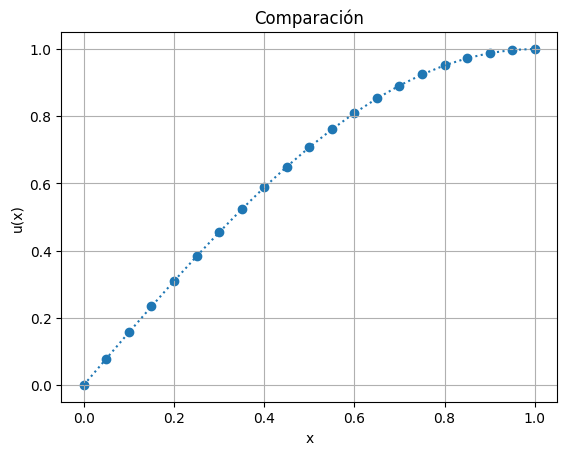

In [6]:
x=np.linspace(0,1,21)

U,_,_=femcode2dm(x,f,g)

plt.scatter(x,g(x))
plt.plot(x,U,label="aprox", linestyle=':')
#plt.plot(x,np.fabs(U-U_i))

plt.xlabel('x')
plt.ylabel('u(x)')
#titulo='max err: '+np.fabs((U-U_i).max()).astype(str)
titulo='Comparación'
plt.title(titulo)

plt.grid()
plt.show()
